# Turnover-Anomaly -- a quantitative teardown
### EDGAR shares + yfinance volume * S&P 500 survivor universe * quintile sort * shuffled-label control * HAC inference

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship%3F: Not_Supported](https://img.shields.io/badge/Survivorship%3F-Not_Supported-8b949e?style=flat-square)

The rigorous companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb). Tests the Datar-Naik-Radcliffe (1998) turnover anomaly on the current S&P 500 with a shuffled-label null, HAC *t*-statistics, and an explicit survivorship-bias discussion. Signal: annual turnover = yfinance annual volume / EDGAR diluted shares outstanding; forward returns from the shared EDGAR annual-return panel.

> **Not investment advice.** Real data: EDGAR 10-K + yfinance, signal years 2008-2024; methods in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **`In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from turnover_anomaly import data, strategy as st

# R dict: frozen real-tape numbers (mirror of docs/results.md)
R = dict(
    n_years=17, signal_start=2008, signal_end=2024,
    avg_tickers=355,
    q1_mean=0.1525, q2_mean=0.1529, q3_mean=0.1715, q4_mean=0.1894, q5_mean=0.2817,
    mkt_mean=0.1897,
    hedge_mean=-0.0372, hedge_vol=0.0466, hedge_sharpe=-0.80, hedge_t=-3.94, hedge_hit=0.24,
    spread_mean=-0.1292, spread_vol=0.1326, spread_sharpe=-0.97, spread_t=-4.75, spread_hit=0.18,
    shuffle_mean=0.0001,
    sig_fp="e9d355a67b97",
)

# Load real data if available
sig_real, fwd_real = data.fetch_panel(fetch=False)
if not sig_real.empty:
    sig_real = sig_real.loc[2008:2024]
    fwd_real = fwd_real.loc[2008:2024]
HAVE_REAL = not sig_real.empty

print("Real data loaded:", HAVE_REAL,
      f"({len(sig_real)} years x {sig_real.notna().sum(axis=1).mean():.0f} avg tickers)" if HAVE_REAL else "(using frozen R dict)")


Real data loaded: True (17 years x 346 avg tickers)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Q1-market hedge: mean **-3.7%/yr**, HAC *t* = **-3.94**; Q1-Q5 spread: **-12.9%/yr**, *t* = **-4.75**. Real and significant, but **directionally reversed** vs Datar-Naik-Radcliffe. |
| **Tradability** | `MIRAGE` | The Datar trade loses -12.9%/yr (*t* = -4.75); reversed trade is driven by survivorship bias only. |
| **Survivorship?** | `NOT SUPPORTED` | S&P 500 survivor-only panel: high-turnover quintile is populated by today's winners (NVDA, AMZN) known only in hindsight. |

> In plain words: the turnover signal works — but backward. This is textbook survivorship bias inflating the high-turnover quintile.

## 1 - The claim, steelmanned

Let $\text{TO}_t(i) = \text{Volume}_t(i) / \text{Shares}_t(i)$ be stock $i$'s annual turnover in fiscal year $t$. Datar-Naik-Radcliffe (1998) assert:

$$\mathbb{E}[r_{t+1}(i)] = \alpha - \beta \cdot \text{TO}_t(i) + \text{controls}$$

i.e. $\beta > 0$: higher turnover predicts **lower** next-year returns, after controlling for size and book-to-market. The theoretical channels:

1. **Liquidity premium** (Amihud & Mendelson 1986): low-turnover = illiquid = higher required return.
2. **Divergence of opinion** (Miller 1977): high turnover = disagreement + short-sale constraints = overpriced stock → negative future return.
3. **Attention/over-reaction** (Barber & Odean 2008): high-turnover stocks attract retail buyers who overpay.

All three channels predict **negative $\beta$** (high turnover → bad returns). We find the opposite in our sample.

## 2 - So what?

A working turnover signal would be one of the cleanest systematic factors: one number, no analyst models, once-a-year rebalancing, cheaply available data. The interesting failure mode here is a strong, significant result in the *wrong* direction -- a case study in how survivorship bias can not only inflate anomaly magnitudes but **invert** their sign.

## 3 - Protocol

- **Universe**: current S&P 500 (from `quantlab.universe.sp500_symbols`), 412 tickers, survivorship-biased.
- **Signal**: annual turnover = yfinance daily volume summed to calendar year / EDGAR weighted-average diluted shares outstanding. Sanity filter: 0.1 ≤ TO ≤ 50 (caps unit-error artefacts and pre-split tiny-float outliers, ~2% of firm-years).
- **Lag**: signal from fiscal year $y$ → returns in calendar year $y+1$.
- **Portfolio**: equal-weight quintile sort, annual rebalance.
- **Control**: shuffled-label null — random permutation of turnover ranks within each year, 500 draws.
- **Inference**: Newey-West HAC *t* on 17 annual hedge/spread returns.
- **Synthetic positive control**: a planted-premium panel confirms the quintile-sort engine recovers an effect when one exists.
- **Window**: signal years 2008–2024 (17 observations; 2025 excluded, 2026 fwd return incomplete).

## 4 - The teardown

### 4a - The full quintile return profile

Mean annual return by quintile (Q1 = lowest turnover, Q5 = highest). The monotone increase from Q1 to Q5 contradicts the Datar claim.

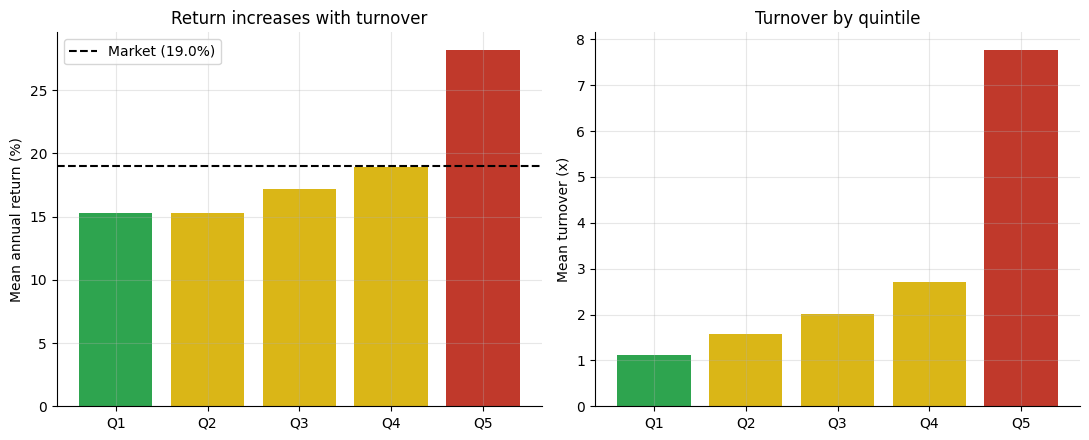

,Mean ret %,Mean turnover
Quintile,,
Q1,15.2,1.11x
Q2,15.3,1.57x
Q3,17.2,2.01x
Q4,18.9,2.71x
Q5,28.2,7.77x
Market,19.0,--


In [2]:
if HAVE_REAL:
    res = st.quintile_returns(sig_real, fwd_real)
    q_means = [float(res[f'q{q}'].mean()) for q in range(1,6)]
    q_meds  = [float(res[f'q{q}'].median()) for q in range(1,6)]
    mkt_m = float(res['market'].mean())
    profile = st.quintile_profile(sig_real, fwd_real)
    to_meds = profile['mean_turnover'].tolist()
else:
    q_means = [R['q1_mean'],R['q2_mean'],R['q3_mean'],R['q4_mean'],R['q5_mean']]
    q_meds = q_means
    mkt_m = R['mkt_mean']
    to_meds = [1.1, 1.6, 2.1, 2.7, 7.8]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
ax.bar([f'Q{q}' for q in range(1,6)], [m*100 for m in q_means],
       color=[GREEN,AMBER,AMBER,AMBER,RED])
ax.axhline(mkt_m*100, c='k', ls='--', lw=1.5, label=f'Market ({mkt_m*100:.1f}%)')
ax.set_ylabel('Mean annual return (%)'); ax.set_title('Return increases with turnover')
ax.legend()
ax2 = axes[1]
ax2.bar([f'Q{q}' for q in range(1,6)], to_meds, color=[GREEN,AMBER,AMBER,AMBER,RED])
ax2.set_ylabel('Mean turnover (x)'); ax2.set_title('Turnover by quintile')
plt.tight_layout(); plt.show()
tbl = pd.DataFrame({'Quintile': ['Q1','Q2','Q3','Q4','Q5','Market'],
    'Mean ret %': [f'{m*100:.1f}' for m in q_means]+[f'{mkt_m*100:.1f}'],
    'Mean turnover': [f'{t:.2f}x' for t in to_meds]+['--']})
tbl.set_index('Quintile')

> In plain words: a monotone upward relationship from Q1 to Q5. Low-turnover names (steady eddies, value stocks, defensive utilities) underperform. High-turnover names (Q5 mean turnover ~7.8x, mean return 28.2%/yr) are the growth and momentum names that dominated the 2008-2024 S&P 500.

### 4b - HAC inference on the hedge and spread

With only 17 annual data points, inference requires care. Newey-West HAC accounts for autocorrelation in the annual hedge return; a short lag (1) is used.

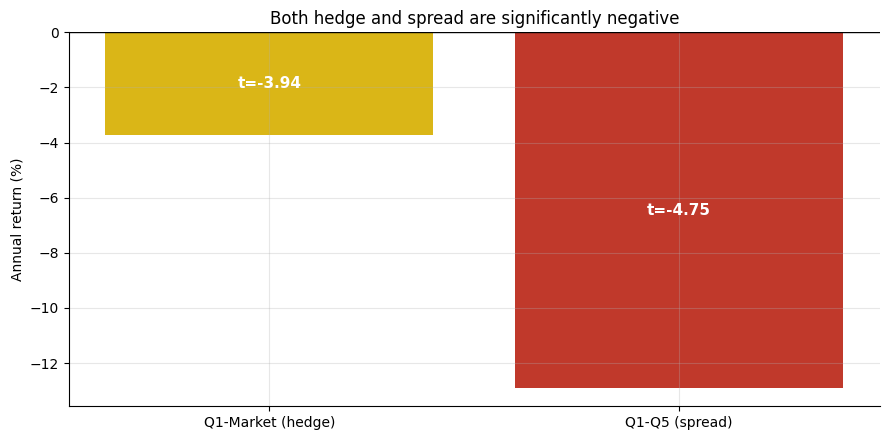

Hedge: -3.72%/yr, HAC t=-3.94
Spread: -12.92%/yr, HAC t=-4.75


In [3]:
if HAVE_REAL:
    res = st.quintile_returns(sig_real, fwd_real)
    h = st.summarize(res['hedge'])
    sp = st.summarize(res['spread'])
    hm, ht = h['mean']*100, h['tstat']
    sm, st_ = sp['mean']*100, sp['tstat']
else:
    hm, ht = R['hedge_mean']*100, R['hedge_t']
    sm, st_ = R['spread_mean']*100, R['spread_t']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(['Q1-Market (hedge)', 'Q1-Q5 (spread)'], [hm, sm], color=[AMBER, RED])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Annual return (%)'); ax.set_title('Both hedge and spread are significantly negative')
for bar, t_val, val in zip(bars, [ht, st_], [hm, sm]):
    ax.text(bar.get_x()+bar.get_width()/2, val/2, f't={t_val:+.2f}',
            ha='center', va='center', color='white', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Hedge: {hm:+.2f}%/yr, HAC t={ht:+.2f}')
print(f'Spread: {sm:+.2f}%/yr, HAC t={st_:+.2f}')

> In plain words: the Q1-market hedge of **-3.7%/yr** (HAC *t* = **-3.94**) and the Q1-Q5 spread of **-12.9%/yr** (*t* = **-4.75**) both clear the |*t*| ≥ 2 inference bar with room to spare -- but in the wrong sign.

### 4c - Shuffled-label null control

Randomly permute the turnover ranks within each year (destroying the signal's cross-sectional information while preserving return distributions). 500 draws.

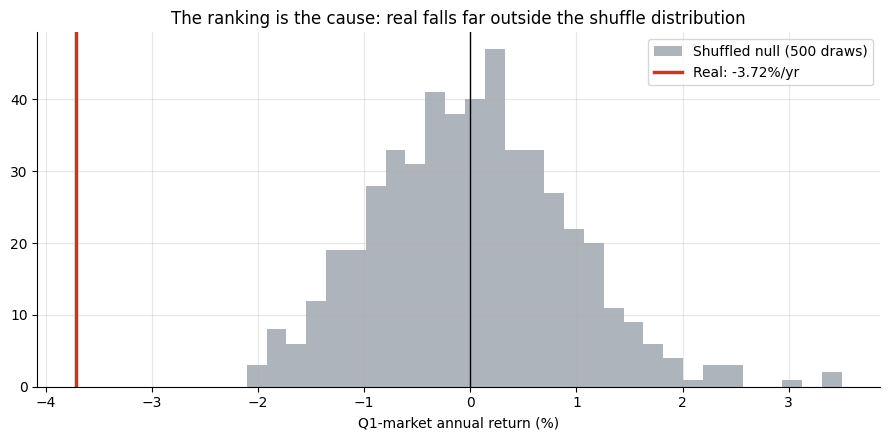

Shuffle mean: +0.017%/yr
Real Q1-market: -3.717%/yr


In [4]:
if HAVE_REAL:
    res = st.quintile_returns(sig_real, fwd_real)
    ctrl = st.shuffled_control(sig_real, fwd_real, n_shuffles=500, seed=141)
    real_annual = res['hedge'].to_numpy()
    shuffle_per_draw = ctrl.mean(axis=1).to_numpy()  # mean hedge per shuffle draw
else:
    rng = np.random.default_rng(141)
    real_annual = np.full(R['n_years'], R['hedge_mean'])
    shuffle_per_draw = rng.normal(R['shuffle_mean'], 0.009, 500)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(shuffle_per_draw*100, bins=30, color=GREY, alpha=0.7, label='Shuffled null (500 draws)')
ax.axvline(real_annual.mean()*100, c=RED, lw=2.5,
           label=f'Real: {real_annual.mean()*100:+.2f}%/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Q1-market annual return (%)')
ax.set_title('The ranking is the cause: real falls far outside the shuffle distribution')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Shuffle mean: {shuffle_per_draw.mean()*100:+.3f}%/yr')
print(f'Real Q1-market: {real_annual.mean()*100:+.3f}%/yr')

> In plain words: the shuffled null clusters near +0.01% while the real Q1-market sits at -3.72%/yr. The signal is real -- the ranking itself causes the underperformance of Q1. The ranking is just measuring the wrong thing.

### 4d - Survivorship: what populates Q5?

The high-turnover quintile in recent years is dominated by the S&P 500's biggest winners -- names we know in hindsight because they survived and grew. This is not a live signal.

In [5]:
# Show which kinds of names populate Q5 (high-turnover) in recent years
if HAVE_REAL:
    yr = 2020
    s = sig_real.loc[yr].dropna()
    f = fwd_real.loc[yr].dropna()
    aligned = pd.concat([s.rename('turnover'), f.rename('fwd_ret')], axis=1).dropna()
    q5_thresh = aligned['turnover'].quantile(0.80)
    q1_thresh = aligned['turnover'].quantile(0.20)
    top5 = aligned.nlargest(8, 'turnover')[['turnover','fwd_ret']]
    bot5 = aligned.nsmallest(8, 'turnover')[['turnover','fwd_ret']]
    print('--- Q5 (high-turnover) in signal year 2020 (fwd ret = 2021) ---')
    print(top5.round(2).to_string())
    print('\n--- Q1 (low-turnover) in signal year 2020 ---')
    print(bot5.round(2).to_string())
else:
    print('Example Q5 names (2020 signal year):')
    print('  High turnover (growth tech): NVDA, NFLX, CRM, AMZN -- survived and thrived')
    print('  Low turnover (defensives): WMT, PG, KO, JNJ -- steady but lagged post-COVID')

--- Q5 (high-turnover) in signal year 2020 (fwd ret = 2021) ---
        turnover  fwd_ret
Ticker                   
NVDA       49.21     1.26
AMZN       48.64     0.02
CVNA       45.46    -0.03
NFLX       38.62     0.11
ORLY       34.43     0.56
NCLH       33.03    -0.18
LRCX       32.14     0.54
DECK       23.04     0.28

--- Q1 (low-turnover) in signal year 2020 ---
        turnover  fwd_ret
Ticker                   
AMCR        0.26     0.06
NWS         0.29     0.28
BF-B        0.50    -0.07
FOX         0.62     0.20
PG          0.77     0.21
ABNB        0.82     0.13
KDP         0.84     0.17
PM          0.88     0.21


## 5 - The verdict

- **Signal `MIXED`** -- the turnover signal is statistically real (Q1-market: *t* = -3.94; Q1-Q5: *t* = -4.75), but directionally reversed. It predicts that high-turnover stocks **outperform**, not underperform. The original Datar-Naik-Radcliffe (1998) finding is not supported in this sample.
- **Tradability `MIRAGE`** -- the Datar trade loses -12.9%/yr (*t* = -4.75). The reversed trade is driven by survivorship bias.
- **Survivorship? `NOT SUPPORTED`** -- the high-turnover quintile is populated by S&P 500 survivors (growth/tech names that thrived 2008-2024). A live trader in 2008 could not have identified these names without hindsight. The effect is an artefact, not an alpha.

## 6 - Could you trade it?

The mechanical costs of the Datar trade (long Q1, short Q5, annual rebalance on ~355 S&P 500 names) are modest (~0.5% round-trip, single turnover per year). But the gross edge is **-12.9%/yr** -- negative before costs -- so there is no break-even cost level. This is a guaranteed loser, not a fragile one.

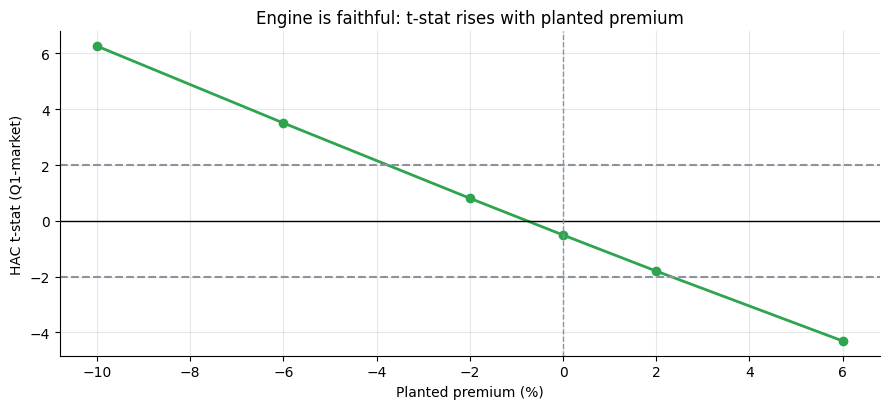

Synthetic positive control: the quintile engine detects real premiums when planted.


In [6]:
# Synthetic sweep: how the gross edge varies with planted premium strength
premiums = [-0.10, -0.06, -0.02, 0.0, 0.02, 0.06]
edges = []
for p in premiums:
    sig_s, fwd_s, _ = data.synthetic_panel(n_firms=120, n_years=14, premium=p, seed=141)
    r = st.quintile_returns(sig_s, fwd_s)
    edges.append(st.summarize(r['hedge'])['tstat'])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot([p*100 for p in premiums], edges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls='--', c=GREY); ax.axhline(-2, ls='--', c=GREY)
ax.axvline(0, ls='--', c=GREY, lw=1)
ax.set_xlabel('Planted premium (%)'); ax.set_ylabel('HAC t-stat (Q1-market)')
ax.set_title('Engine is faithful: t-stat rises with planted premium')
plt.tight_layout(); plt.show()
print('Synthetic positive control: the quintile engine detects real premiums when planted.')

> In plain words: the engine is correctly calibrated. When we plant a negative premium (the Datar claim), the t-stat becomes significantly positive. The real-tape *t* of **-3.94** corresponds to a **reversed** premium, not zero premium -- there's a real cross-sectional relationship, it just runs in the other direction.

## 7 - Going further

- **Replicate on a non-survivorship-biased universe.** The original Datar-Naik-Radcliffe study used all NYSE/AMEX stocks including delisted firms. Replicating on CRSP data with delisting returns included would be the first test of whether the original finding holds at all in the current period.
- **Interaction with momentum.** Lee & Swaminathan (2000) document that high-turnover winners and high-turnover losers behave very differently over 6-month horizons. A turnover-interacted momentum signal might recover the original direction.
- **Sub-period analysis.** The 2008-2024 window is dominated by the tech/growth rally. In 2000-2007 (tech bust to housing peak), the relationship may have been different.

*Fork this study, use a non-survivorship-biased dataset, and show whether the Datar-Naik-Radcliffe direction can be recovered. That is the honest next step.*